In [1]:
import random
from collections import Counter

def chinese_restaurant_process(num_customers, alpha):
    """
    Simulates a Chinese Restaurant Process (CRP).

    Parameters:
        num_customers (int): Number of customers to seat in the restaurant.
        alpha (float): Concentration parameter controlling the probability of sitting at a new table.

    Returns:
        list: A list of integers where each element represents the table assigned to a customer.
    """
    tables = []  # List of tables, where each entry counts the number of customers at that table
    assignments = []  # List of table assignments for each customer

    for customer in range(num_customers):
        if len(tables) == 0:  # First customer starts the first table
            tables.append(1)
            assignments.append(1)
        else:
            # Calculate the probabilities for existing tables and the new table
            probs = [count / (customer + alpha) for count in tables] + [alpha / (customer + alpha)]

            # Sample from the probabilities
            table_choice = random.choices(range(len(tables) + 1), probs)[0]

            if table_choice == len(tables):  # New table
                tables.append(1)
            else:  # Existing table
                tables[table_choice] += 1

            assignments.append(table_choice + 1)  # Assign table (1-indexed)

    return assignments

# Example usage
num_customers = 100
alpha = 2.0
seating = chinese_restaurant_process(num_customers, alpha)

print(f"Seating arrangement for {num_customers} customers with alpha={alpha}:")
print(Counter(seating))


Seating arrangement for 100 customers with alpha=2.0:
Counter({3: 32, 1: 30, 4: 17, 2: 6, 8: 4, 9: 4, 6: 3, 5: 1, 7: 1, 10: 1, 11: 1})


The classical CRP uses a fixed alpha. The idea is to use Burr to manage an LLM that maintains a description for each table. The LLM can then be used to generate text based on the table assignments. The LLM can be updated as new customers arrive, and the text can be generated based on the current state. We need a state machine that chooses between adding a customer to a table and starting a new table. Very simple state machine needed, but makes things trackable.

To make the idea work, we need the LLM to do work to generate text based on the table assignments.

- it considers adding each customer to each table, based on the content summary for the table
- as part of this it generates a new content summary for each customer/table pair.


In [2]:
from burr.core import action, State, ApplicationBuilder, when, expr
from typing import List,Any

@action(reads=[], writes=["customers",
                          "num_customers",
                          "tables"])
def get_customers(state: State, customers:List[Any]) -> State:
    return state.update(customers=customers,
                        num_customers  = len(customers),
                        tables=[])

@action(reads=["customers","tables","num_customers"], writes=["tables","customers","num_customers"])
def choose_table(state: State, alpha: float) -> State:
    customers = state["customers"]
    customer = customers[0]
    tables = state["tables"]
    if len(tables) == 0:
        tables.append([customer])
    else:
        # alphas in next line are due to be replaced by LLM choice.
        probs = [len(table) / (len(customers) + alpha) for table in tables] + [alpha / (len(customers) + alpha)]
        table_choice = random.choices(range(len(tables) + 1), probs)[0]
        if table_choice == len(tables):
            tables.append([customer])
        else:
            tables[table_choice].append(customer)
    return state.update(tables=tables,
                        num_customers=state["num_customers"]-1,
                        customers=customers[1:])

@action(reads=["tables"], writes=[])
def finished(state: State) -> State:
    return state




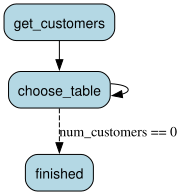

In [3]:
app = (
    ApplicationBuilder()
    .with_actions(get_customers.bind(customers=list(range(100))),
                  choose_table.bind(alpha=5.0),
                  finished)
    .with_transitions(("get_customers", "choose_table"),
                      ("choose_table", "finished",expr("num_customers == 0")),
                      ("choose_table", "choose_table"))
    .with_entrypoint("get_customers")
    .build()
)
app

In [4]:
my_action, result, state = app.run(
    halt_after=["finished"],
)

In [5]:
state['tables']

[[0,
  2,
  4,
  9,
  17,
  19,
  21,
  22,
  24,
  26,
  29,
  36,
  39,
  40,
  41,
  43,
  47,
  48,
  52,
  58,
  60,
  71,
  72,
  74,
  80,
  82,
  83,
  85,
  86,
  88,
  92,
  95,
  98],
 [1, 3, 16, 18, 20, 30, 53, 77, 84, 99],
 [5, 46],
 [6, 10, 11, 70],
 [7,
  12,
  13,
  15,
  23,
  31,
  35,
  44,
  50,
  51,
  54,
  55,
  56,
  57,
  65,
  68,
  69,
  73,
  78,
  87,
  89,
  91,
  97],
 [8, 25, 28, 33, 37, 45, 62, 67, 79, 96],
 [14],
 [27],
 [32],
 [34, 42, 49, 75],
 [38, 61],
 [59, 63, 64, 93],
 [66, 90],
 [76, 81],
 [94]]

In [6]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import random

def calculate_distance_matrix(sentences, model_name='all-MiniLM-L6-v2'):
    """
    Calculates the pairwise cosine distance matrix for a list of sentences using SentenceTransformer embeddings.

    Parameters:
        sentences (list of str): The sentences to process.
        model_name (str): The pre-trained SentenceTransformer model to use.

    Returns:
        np.ndarray: A distance matrix where each entry (i, j) represents the distance between sentence i and j.
    """
    model = SentenceTransformer(model_name)
    embeddings = model.encode(sentences)
    # Convert cosine similarity to a distance metric
    similarity_matrix = cosine_similarity(embeddings)
    distance_matrix = 1 - similarity_matrix
    return distance_matrix


/Users/brewc/PycharmProjects/BleakHouse/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [16]:
from bleak_house.distances import calculate_distance_matrix_bge, dd_crp_with_alpha, dd_crp_with_softmax
# Example usage
if __name__ == "__main__":
    sentences = [
        "The cat sat on the mat.",
        "A dog is running.",
        "Dogs are keen on running.",
        "Alsatians are a species of dog.",
        "A dog is running around in the grass.",
        "The mat was very comfortable.",
        "Dogs love running around in the grass.",
        "Cats are usually very quiet animals.",
        "The tiger is the largest cat species.",
        "Oranges are not the only fruit.",
        "In Bavaria, lemons are known as 'citrons'.",
        "The fruit of a lemon tree can be used for many purposes.",
        "Is an orange a type of lemon?",
        "Lemons are sour, but oranges are sweet.",
        "Is an Alsatian a type of cat?",
        "Cats are not so keen on running.",
        "Elephants can run faster than cats.",
        "Three elephants are running around in the grass.",
        "Elephants are the largest land animals.",
        "Elephants are known for their large ears.",
        "Two dogs are playing in the park.",
        "The park is full of dogs and cats.",
        "Dogs and cats are not always friends.",
    ]

    # Step 1: Calculate distance matrix using the previously defined `calculate_distance_matrix_bge`
    distance_matrix = calculate_distance_matrix_bge(sentences)

    # Step 2: Apply dd-CRP with softmax
    alpha = 1.0         # Concentration parameter
    seed = 42           # Seed for replicability
    temperature = 3.0   # Temperature for softmax
    assignments, clusters = dd_crp_with_softmax(sentences, distance_matrix, alpha=alpha, seed=seed, temperature=temperature)

    # Display results
    print(f"Cluster assignments with alpha={alpha}, seed={seed}, temperature={temperature}:", assignments)
    for idx, cluster in enumerate(clusters):
        print(f"Cluster {idx + 1}:")
        for sentence_index in cluster:
            print(f"  - {sentences[sentence_index]}")



Cluster assignments with alpha=1.0, seed=42, temperature=3.0: [0, 0, 1, 1, 0, 2, 2, 2, 0, 0, 0, 3, 0, 3, 2, 1, 0, 0, 1, 0, 0, 2, 4]
Cluster 1:
  - The cat sat on the mat.
  - A dog is running.
  - A dog is running around in the grass.
  - The tiger is the largest cat species.
  - Oranges are not the only fruit.
  - In Bavaria, lemons are known as 'citrons'.
  - Is an orange a type of lemon?
  - Elephants can run faster than cats.
  - Three elephants are running around in the grass.
  - Elephants are known for their large ears.
  - Two dogs are playing in the park.
Cluster 2:
  - Dogs are keen on running.
  - Alsatians are a species of dog.
  - Cats are not so keen on running.
  - Elephants are the largest land animals.
Cluster 3:
  - The mat was very comfortable.
  - Dogs love running around in the grass.
  - Cats are usually very quiet animals.
  - Is an Alsatian a type of cat?
  - The park is full of dogs and cats.
Cluster 4:
  - The fruit of a lemon tree can be used for many purpose

Cluster assignments with alpha=5.0: [0, 1, 1, 2, 2, 2, 2, 3, 1, 4, 5, 2, 4, 2, 5, 2, 2, 6, 0, 5, 7, 8, 9]
Cluster 1:
  - The cat sat on the mat.
  - Elephants are the largest land animals.
Cluster 2:
  - A dog is running.
  - Dogs are keen on running.
  - The tiger is the largest cat species.
Cluster 3:
  - Alsatians are a species of dog.
  - A dog is running around in the grass.
  - The mat was very comfortable.
  - Dogs love running around in the grass.
  - The fruit of a lemon tree can be used for many purposes.
  - Lemons are sour, but oranges are sweet.
  - Cats are not so keen on running.
  - Elephants can run faster than cats.
Cluster 4:
  - Cats are usually very quiet animals.
Cluster 5:
  - Oranges are not the only fruit.
  - Is an orange a type of lemon?
Cluster 6:
  - In Bavaria, lemons are known as 'citrons'.
  - Is an Alsatian a type of cat?
  - Elephants are known for their large ears.
Cluster 7:
  - Three elephants are running around in the grass.
Cluster 8:
  - Two dogs

KeyboardInterrupt: 